## Cookie Cats — A/B Test Analysis

### Does Moving the Progression Gate Affect Player Retention?

Player retention is a key performance metric in mobile games. Small changes in game design can influence whether new players continue playing or abandon the game after the first sessions.

In the mobile puzzle game Cookie Cats, progression is occasionally interrupted by gates — points where players must wait, invite friends, or make an in-app purchase before continuing. These gates are intended to slow progression and encourage players to return later.

Originally, the first gate appeared at level 30. The development team tested whether moving this gate later in the game (level 40) would allow players more time to engage with the gameplay and improve retention.

To evaluate this change, the company conducted a randomized A/B test with more than 90,000 players:

- Group A: gate at level 30

- Group B: gate at level 40

The main question of this analysis is:

Does delaying the first progression gate increase player retention?

Two retention metrics are used to evaluate the effect:

- Day 1 retention: whether a player returned the day after installation

  Day 7 retention: whether a player returned within the first week

In addition to comparing retention rates between the two groups, the analysis includes data cleaning, outlier inspection, statistical hypothesis testing, behavioral segmentation of players, and a predictive model to explore patterns in player engagement.

#### What This Notebook Covers:

1. Exploratory data analysis of player activity and retention

2. Data quality checks and outlier handling

3. Statistical testing (Chi-Square, Two-proportion z-test, confidence intervals)

4. Player segmentation based on retention behavior

5. Logistic regression model for player outcome prediction

6. Business interpretation of results and product recommendations

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd
import numpy as np
import scipy 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

#### Phase 1: Exploratory Data Analysis of player activity and retention

In [6]:
df = pd.read_csv("cookie_cats.csv")
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


The dataset contains 90189 total player records. There are no missing and negative values across the key columns but we see one extreme value in sum_gamerounds (will handle it later). 

We now check:

- Are the test groups balanced?

- How much players engage with the game (in terms of rounds played)?

- What are the retention rates across both groups?

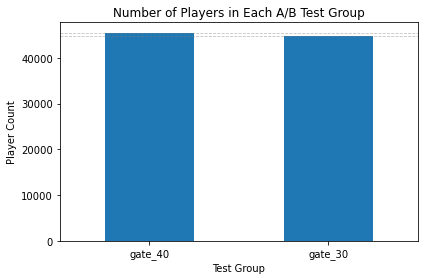

In [29]:
# Groups should be balanced to reduce bias in comparison
# Visual check

ax = df['version'].value_counts().plot(kind='bar')
plt.title("Number of Players in Each A/B Test Group")
plt.xlabel("Test Group")
plt.ylabel("Player Count")
plt.xticks(rotation=0)

# Add horizontal lines at each bar height
for bar in ax.patches:
    plt.axhline(y=bar.get_height(), linestyle='--', linewidth=0.8, alpha=0.5, color='gray')

plt.tight_layout()
plt.show()

In [7]:
# Group sizes - numerica check 

print(df.groupby('version').size())

version
gate_30    44700
gate_40    45489
dtype: int64


We have a difference of 789 players (1.7%) between the groups which is a very small and acceptable imbalance. We should worry when groups differ by more than 10%.

#### Phase 2. Data quality checks and outlier handling

Since the groups are balanced, we can proceed with comparing behavioral outcomes: retention and game rounds played. But first check for outliers.

In [8]:
print(df['sum_gamerounds'].describe())
print("Skew:", df['sum_gamerounds'].skew()) 

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64
Skew: 185.43631284312502


The distribution is severly skewed on the right (skew > 3). 

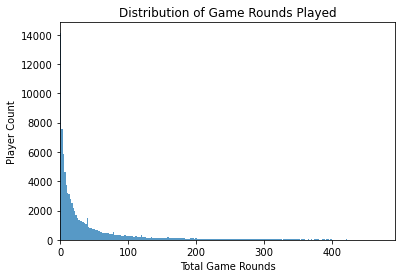

In [30]:
# Clip x-axis to 99th percentile to remove extreme outliers

x_max = df['sum_gamerounds'].quantile(0.99)

ax = sns.histplot(data=df, x='sum_gamerounds')
plt.title("Distribution of Game Rounds Played")
plt.xlabel("Total Game Rounds")
plt.ylabel("Player Count")

ax.set_xlim(0, x_max)  # Cut off the extreme right tail

plt.show()

As we know the distribution is heavily right-skewed, meaning that many players played a very few game rounds. We also observe a small number of highly engaged players who played hundreds (even thousands)of rounds.

This type of distribution is common in free-to-play mobile games. 

The distribution of total game rounds is strongly right-skewed. Most players complete relatively few rounds, while a small fraction of highly engaged users play substantially more. These high values represent legitimate gameplay behavior rather than measurement errors and are therefore retained in the analysis.

In [10]:
# detect that one extreme outlier

df[df['sum_gamerounds'] > df['sum_gamerounds'].quantile(0.99999)]  # Found it!

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


In [12]:
# Remove this one extreme outlier

df_clean = df[df['sum_gamerounds'] != 49854] 

# Check the column statistics again

df_clean['sum_gamerounds'].describe()

count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64

In [13]:
# Check median instead of mean because the data is skewed.

df_clean['sum_gamerounds'].median()

16.0

- Median = 16 rounds

- Mean = 51 rounds

The large gap between the mean and the median indicates a strong right-skewed distribution.

This means that most players complete relatively few rounds, while a small number of highly active players complete very large numbers of rounds, pulling the average upward.

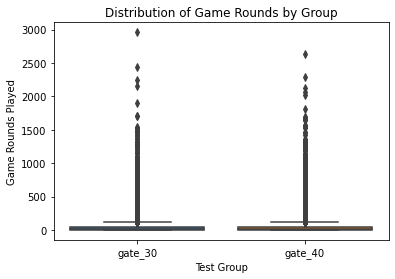

In [13]:
# Plot the game rounds by group

sns.boxplot(data=df_clean, x="version", y="sum_gamerounds")
plt.title("Distribution of Game Rounds by Group")
plt.xlabel("Test Group")
plt.ylabel("Game Rounds Played")

plt.show()

We cannot see any important details in these boxplots because the numerous outliers dominate the y-axis. 

There is a standard statistical approach to deal with outliers:

   Step 1. Detect outliers — IQR method

   Step 2. Understand if there are too many (< 1% fine - safe to remove,1–5% moderate -investigate first, > 5% too many — removing distorts the data).

   Step 3. 
   - Remove observations. If outliers represent measurement errors, corrupted logs, or impossible values, they should be removed from the dataset.

   - Winsorization (capping).If extreme values are valid but disproportionately influence summary statistics, they can be capped at a high percentile (for example the 99th percentile) to reduce their impact while preserving most observations.

   - Transformation of the variable. For highly skewed behavioral data, applying a log transformation (e.g., log1p) can compress the long tail of the distribution and make patterns easier to visualize and analyze.
   
   - Use robust statistics. When extreme values reflect genuine behavior ( in our case highly engaged players), it may be preferable to retain all observations and rely on robust measures such as the median, quantiles, and non-parametric statistical tests, which are less sensitive to extreme values than the mean.

In [26]:
# Step 1. Detecting outliers with IQR method.

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]  # fixed
    return outliers, lower_bound, upper_bound

outliers, lower, upper = detect_outliers_iqr(df_clean, 'sum_gamerounds')
print(f"Found {len(outliers)} outliers")
print(f"Bounds: [{lower:.2f}, {upper:.2f}]") # 

Found 10176 outliers
Bounds: [-64.00, 120.00]


The negative lower bound equal to -64 game rounds is  a nonsense and can be ignored because no real data falls there. We only notice the upper bound = 120, which means that any player wo played more than 120 game rounds is flagged as an outlier.

In [15]:
 # Step 2. Are the outliers too many?
    
print(f"Outlier count: {len(outliers)}")
print(f"Outlier %: {len(outliers)/len(df)*100:.2f}%")

Outlier count: 10176
Outlier %: 11.28%


Yes, they are many.But we will not use the capped data for analysis as we believe these data points represent real gaming behaviour of highly engaged players. We will oly use capped data for a boxplot visualisation below.

In [74]:
# Retention rates per group
retention_summary = df_clean.groupby('version')[['retention_1', 'retention_7']].mean() * 100
retention_summary.columns = ['Day1_Retention', 'Day7_Retention']
print(retention_summary.round(2).astype(str) + '%')

        Day1_Retention Day7_Retention
version                              
gate_30         44.82%         19.02%
gate_40         44.23%          18.2%


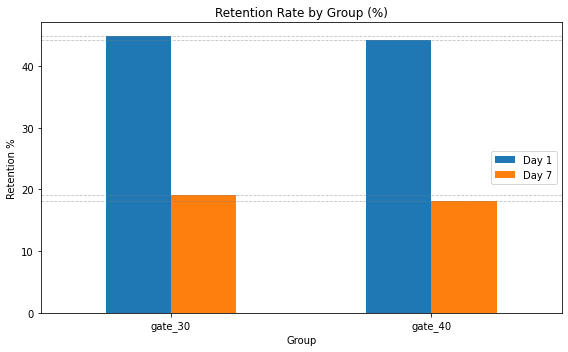

<Figure size 432x288 with 0 Axes>

In [75]:
# Visualize retention rates by group and by day.
retention_summary.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title("Retention Rate by Group (%)")
plt.ylabel("Retention %")
plt.xlabel("Group")
plt.legend(["Day 1", "Day 7"])

# Add horizontal lines at each retention value
for val in retention_summary.values.flatten():
    plt.axhline(y=val, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

In [27]:
# A new df with capped values. For a clearer visualization below.
df_capped = df_clean.copy()
df_capped['sum_gamerounds'] = df_capped['sum_gamerounds'].clip(upper=upper)

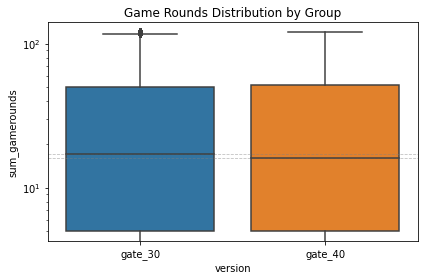

In [28]:
# Game rounds distribution by group (capped data)
sns.boxplot(data=df_capped, x='version', y='sum_gamerounds')
plt.title("Game Rounds Distribution by Group")
plt.yscale('log')

# Add horizontal lines at median values for each group
for version in df_capped['version'].unique():
    median = df_capped[df_capped['version'] == version]['sum_gamerounds'].median()
    plt.axhline(y=median, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')

plt.tight_layout()
plt.show()

We observe a few subtle differences but we need to test them to unsderstand if these differences are statistically significant.

#### Phase 3: Statistical Testing

Selecting the correct statistical test requires evaluating three properties of the data: its distribution shape, the nature of the outcome variable, and the sample size.

In our case n ≈ 45000 which makes normality is almost irrelevant due to Central Limit Theorem but we will still perform it for educational purposes.

1. Visual Normality Check.
2. Actual Testing
3. Understand p-value
4. Effect Size (Cohen´s H) — Is the difference meaningful?
5. Confidence Interval — Where does the true difference lie?

In [15]:
# Split version data into two separate groups

gate_30 = df_clean[df_clean['version'] == 'gate_30']
gate_40 = df_clean[df_clean['version'] == 'gate_40']

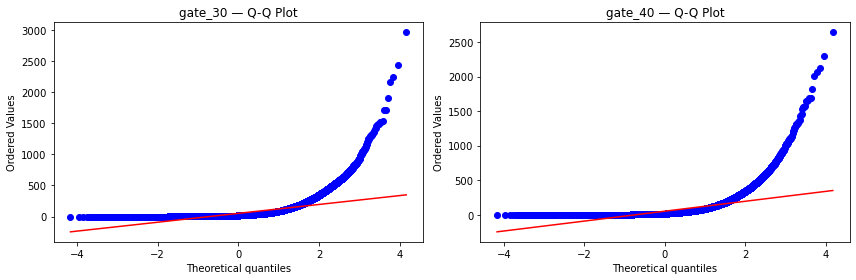

In [18]:
# Visual Normality Check

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Q-Q Plot — should look like a straight line if normal
for ax, (name, group) in zip(axes, [('gate_30', gate_30), ('gate_40', gate_40)]):
    stats.probplot(group['sum_gamerounds'], dist="norm", plot=ax)
    ax.set_title(f"{name} — Q-Q Plot")

plt.tight_layout()
plt.show()

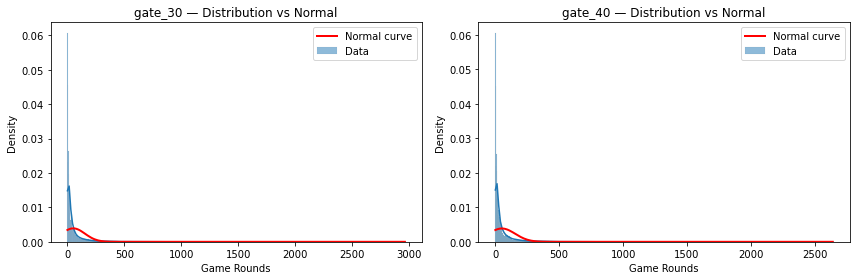

In [24]:
# Histogram — should look like bell curve if normal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, group) in zip(axes, [('gate_30', gate_30), ('gate_40', gate_40)]):
    # Histogram with KDE
    sns.histplot(group['sum_gamerounds'], ax=ax, kde=True, stat='density', alpha=0.5, label='Data')
    
    # Normal distribution bell curve overlay
    mu, std = group['sum_gamerounds'].mean(), group['sum_gamerounds'].std()
    x = np.linspace(group['sum_gamerounds'].min(), group['sum_gamerounds'].max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2, label='Normal curve')
    
    ax.set_title(f"{name} — Distribution vs Normal")
    ax.set_xlabel("Game Rounds")
    ax.set_ylabel("Density")
    ax.legend()
    
plt.tight_layout()
plt.show()

The data points in both groups are away from the straight line and bell shape. We have proved that the distributions of our both groups are not normal.

Thus, we cannot use  parametric tests that assume  normality. 

Instead, we use non-parametric methods because our data points are strongly skewed.

##### Chi-Square test, Two-proportion z-test

Because our retention_1 and retention_7 are binary variables (0/1), differences between groups are evaluated using proportion-based statistical tests which are Chi-Square and Two-proportion z-test. 

Why to run both? 

As these tests agree with one another, we cross-validate our results and also show our statistical thoroughness. Additionaly,  Z-test results show us a direction (positive/negative) while Chi-Square only gives magnitude.

- Positive Z = gate_30 proportion is HIGHER than gate_40 (
- Negative Z= gate_30 proportion is LOWER than gate_40

In [9]:
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# Chi-Square for Day 1
contingency_d1 = pd.crosstab(df_clean['version'], df_clean['retention_1'])
chi2_d1, p_d1, _, _ = chi2_contingency(contingency_d1)
print(f"Day 1 Chi-Square p-value: {p_d1:.4f}")

# Chi-Square for Day 7
contingency_d7 = pd.crosstab(df_clean['version'], df_clean['retention_7'])
chi2_d7, p_d7, _, _ = chi2_contingency(contingency_d7)
print(f"Day 7 Chi-Square p-value: {p_d7:.4f}")

# Two-proportion z-test for Day 1
count_d1 = [df_clean[df_clean['version']=='gate_30']['retention_1'].sum(),
            df_clean[df_clean['version']=='gate_40']['retention_1'].sum()]
nobs_d1  = [len(df_clean[df_clean['version']=='gate_30']),
            len(df_clean[df_clean['version']=='gate_40'])]

stat_d1, p_z_d1 = proportions_ztest(count_d1, nobs_d1)
print(f"Day 1 Z-test p-value: {p_z_d1:.4f}")

# Two-proportion z-test for Day 7
count_d7 = [df_clean[df_clean['version']=='gate_30']['retention_7'].sum(),
            df_clean[df_clean['version']=='gate_40']['retention_7'].sum()]
nobs_d7  = [len(df_clean[df_clean['version']=='gate_30']),
            len(df_clean[df_clean['version']=='gate_40'])]

stat_d7, p_z_d7 = proportions_ztest(count_d7, nobs_d7)
print(f"Day 7 Z-test p-value: {p_z_d7:.4f}")

Day 1 Chi-Square p-value: 0.0750
Day 7 Chi-Square p-value: 0.0016
Day 1 Z-test p-value: 0.0739
Day 7 Z-test p-value: 0.0016


Our Hypotheses:

- H₀: There is no difference in retention rates
    between gate_30 and gate_40
    (p_gate30 = p_gate40)

- H₁: There is a significant difference in retention
    rates between gate_30 and gate_40
    (p_gate30 ≠ p_gate40)

Results Interpretation:

- On Day 1 p-value  = 0.0750 > 0.05 - not statistically significant. We cannot reject H₀ of no difference between the versions. The gate position does not significantly affect whether a player returns the day after installation.

- On Day 7 p-value = 0.0016 < 0.05 - statistically significant. We reject H₀: gate position significantly affects whether a player returns one week after installation. Gate_30 retains more players on Day 7.

- Z tests p-values confirms Chi-Square result exactly: the proportion of returning players is significantly higher  in gate_30 than gate_40 on Day 7 while on Day 1 it is not significant.

#### Effect Size
We rememeber that the gate_30 Day 7 retention is 19.02% and  the gate_40 Day 7 retention 18.20%  which produces the difference = 0.82%.

With n ≈ 45000 per group, even this tiny difference produces p < 0.001 and implies  being statistically significant, as we have observed.

But is 0.82% worth re-designing the entire game? Probably not. This is why statisticians always pair p-value with effect size.

In [38]:
# 5: Effect Size — Cohen's H 

from statsmodels.stats.proportion import proportion_effectsize

r1 = df_clean[df_clean['version'] == 'gate_30']['retention_7'].mean()
r2 = df_clean[df_clean['version'] == 'gate_40']['retention_7'].mean()

h = proportion_effectsize(r1, r2)
print(f"Cohen's H: {h:.4f}")
print("Small: 0.2 | Medium: 0.5 | Large: 0.8")

Cohen's H: 0.0210
Small: 0.2 | Medium: 0.5 | Large: 0.8


Our Cohen's h = 0.0210 which is substantially less than 0.2 means that the difference between the two proportions is subtle.

Thus, the difference in Day 7 retention between gate_30 and gate_40 is statistically real but practically tiny. Gate position barely affects the long-term retention.

#### Confidence Interval — Where Does the True Difference Lie?

A confidence interval lying entirely above zero indicates that we are 95% confident the true difference in retention favors gate_30 — the effect is statistically distinguishable from zero.


A confidence interval crossing zero means zero is a plausible value for the true difference — we cannot reject the null hypothesis of no difference between the groups.


A confidence interval lying entirely below zero indicates that we are 95% confident the true difference in retention favors gate_40 — the effect is statistically distinguishable from zero in the opposite direction.

-  If our CI entirely positive = gate_30 is reliably better.

- If our CI crosses zero = difference is uncertain.

- If CI entirely negative = gate_40 is reliably better.


In [81]:
# 6. Confidence Interval 

import numpy as np

def bootstrap_ci(group1, group2, metric, n_bootstrap=1000, ci=95):
    """Bootstrap confidence interval for difference in proportions"""
    diffs = []
    for _ in range(n_bootstrap):
        s1 = group1[metric].sample(len(group1), replace=True).mean()
        s2 = group2[metric].sample(len(group2), replace=True).mean()
        diffs.append(s1 - s2)

    lower = np.percentile(diffs, (100 - ci) / 2)
    upper = np.percentile(diffs, 100 - (100 - ci) / 2)
    mean_diff = np.mean(diffs) * 100

    print(f"\n{metric} — 95% Confidence Interval:")
    print(f"Mean difference: {mean_diff:+.3f}%")
    print(f"CI: [{lower*100:+.3f}%, {upper*100:+.3f}%]")
    if lower > 0 or upper < 0:
        print("→ CI does not cross zero ✅ — difference is real")
    else:
        print("→ CI crosses zero ❌ — difference may not be real")

bootstrap_ci(gate_30, gate_40, 'retention_1')
bootstrap_ci(gate_30, gate_40, 'retention_7')


retention_1 — 95% Confidence Interval:
Mean difference: +0.568%
CI: [-0.069%, +1.216%]
→ CI crosses zero ❌ — difference may not be real

retention_7 — 95% Confidence Interval:
Mean difference: +0.805%
CI: [+0.263%, +1.314%]
→ CI does not cross zero ✅ — difference is real


We are 95% confident that gate_30 retains between +0.263% and +1.314% more players on Day 7 compared to gate_40.

In [77]:
# How many extra players retained at scale

total_players = len(df_clean)
extra_retained_d7 = total_players * 0.00805
print(f"Extra players retained on Day 7: {extra_retained_d7:.0f}")

# Extrapolate to 1M players
print(f"At 1M players: {1000000 * 0.00805:.0f} extra retained players")

Extra players retained on Day 7: 726
At 1M players: 8050 extra retained players


Retention Funnel Analysis.

Of players who came back Day 1, how many survived to Day 7? 

Does gate position affect this drop-off?

In [42]:
# Retention Funnel Analysis

funnel = df_clean.groupby('version')[['retention_1', 'retention_7']].mean() * 100
funnel['drop_off'] = funnel['retention_1'] - funnel['retention_7']
funnel['day7_of_day1'] = (funnel['retention_7'] / funnel['retention_1']) * 100
print(funnel.round(2).astype(str) + '%')

        retention_1 retention_7 drop_off day7_of_day1
version                                              
gate_30      44.82%      19.02%    25.8%       42.43%
gate_40      44.23%       18.2%   26.03%       41.15%


We observe that 42.43% of Day 1 players returned on Day 7 at gate_30 version while at gate_40 version they are fewer 41.15%. The analysis favours gate_30 version.

#### Phase 4. Player behavioral segmentation — Loyal, Lost, Early Churner, Dormant

Not all players are similar.

In gaming there are different types of behavior: 

- Loyal (Retained both days — most valuable players)
- Early Churner (Came back Day 1 but lost by Day 7)
- Dormant Returner (Skipped Day 1 but recovered by Day 7)
- Lost (Never returned — churned immediately)

Let us segment them.

In [64]:
# Define the segments
df_clean['behavior'] = 'Neither'
df_clean.loc[(df_clean['retention_1']==1) & (df_clean['retention_7']==1), 'behavior'] = 'Loyal'
df_clean.loc[(df_clean['retention_1']==1) & (df_clean['retention_7']==0), 'behavior'] = 'Early_Churner'
df_clean.loc[(df_clean['retention_1']==0) & (df_clean['retention_7']==1), 'behavior'] = 'Dormant_Returner'
df_clean.loc[(df_clean['retention_1']==0) & (df_clean['retention_7']==0), 'behavior'] = 'Lost'

# Compare segments between  the groups
behavior_pct = df_clean.groupby(['version', 'behavior']).size().unstack()
behavior_pct = behavior_pct.div(behavior_pct.sum(axis=1), axis=0) * 100

behavior_counts = df_clean.groupby(['version', 'behavior']).size().unstack()
behavior_pct = behavior_counts.div(behavior_counts.sum(axis=1), axis=0) * 100

print("=== Player Counts ===")
print(behavior_counts)
print("\n=== Player % ===")
print(behavior_pct.round(2))

=== Player Counts ===
behavior  Dormant_Returner  Early_Churner   Lost  Loyal
version                                                
gate_30               1825          13358  22840   6676
gate_40               1773          13613  23597   6506

=== Player % ===
behavior  Dormant_Returner  Early_Churner   Lost  Loyal
version                                                
gate_30               4.08          29.88  51.10  14.94
gate_40               3.90          29.93  51.87  14.30


In [65]:
# check the newly added column "behaviour"
df_clean.head()

,userid,version,sum_gamerounds,retention_1,retention_7,behavior
0,116,gate_30,3,False,False,Lost
1,337,gate_30,38,True,False,Early_Churner
2,377,gate_40,165,True,False,Early_Churner
3,483,gate_40,1,False,False,Lost
4,488,gate_40,179,True,True,Loyal


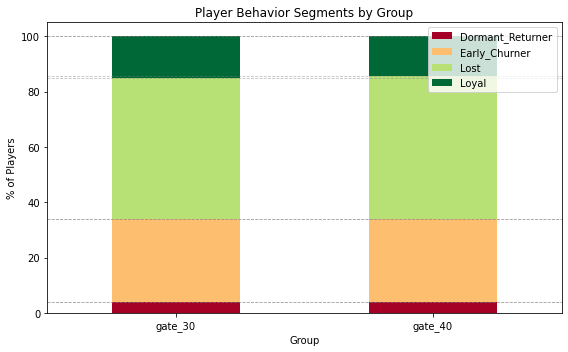

In [78]:
# Visualisation of the segments 

behavior_pct.plot(kind='bar', stacked=True, figsize=(8, 5), rot=0, colormap='RdYlGn')
plt.title("Player Behavior Segments by Group")
plt.ylabel("% of Players")
plt.xlabel("Group")
plt.legend(loc='upper right')

# Add horizontal lines at each cumulative segment boundary

for col_idx, col in enumerate(behavior_pct.columns):
    cumulative = behavior_pct.iloc[:, :col_idx+1].sum(axis=1)
    for val in cumulative.values:
        plt.axhline(y=val, linestyle='--', linewidth=0.8, alpha=0.5, color='gray')

        plt.tight_layout()
plt.show()

We observe similar segmentation with subtle difference in both groups. We run a statistical Chi-Square test to check if segment distribution differs significantly between gate_30 and gate_40.

Question: Is the proportion of Loyal vs Lost players statistically different between groups?

In [55]:
# Chi-Square test

from scipy.stats import chi2_contingency

chi2, p, dof, _ = chi2_contingency(behavior_counts)
print(f"Chi-Square p-value: {p:.4f}")
print(f"Significant: {'✅ Yes' if p < 0.05 else '❌ No'}")

Chi-Square p-value: 0.0130
Significant: ✅ Yes


The distribution of player behavior segments (Loyal, Lost, Early Churner, Dormant) is significantly different between gate_30 and gate_40 — this difference is unlikely to be due to random chance.

Thus, gate position influences how players behave overall — not just retention rates, but the entire pattern of loyalty, churn, and dormancy differs between the two groups.

#### Phase 5. Logistic regression model for player outcome prediction

Now, after we have segmentated the players, we can try to predict their  gaming behaviour using Logistic Regression that estimats the probability of binary outcomes (0/No or 1/Yes) in each segment.

Limitation:  gate version and game rounds alone are not enough to distinguish between all 4 behavioral patterns our predictive model will not have a strong power. A stronger model would need: session frequency, level progression speed, time between sessions, etc.

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Encode version as binary
df_clean['version_encoded'] = (df_clean['version'] == 'gate_30').astype(int)

# 1. Prepare data
X = df_clean[['version_encoded', 'sum_gamerounds']]  # fixed
y = df_clean['behavior']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X_train, y_train)

# 4. Evaluate
print(classification_report(y_test, model.predict(X_test)))

                  precision    recall  f1-score   support

Dormant_Returner       0.00      0.00      0.00       752
   Early_Churner       0.52      0.44      0.47      5410
            Lost       0.73      0.92      0.81      9242
           Loyal       0.73      0.48      0.58      2634

        accuracy                           0.67     18038
       macro avg       0.49      0.46      0.47     18038
    weighted avg       0.63      0.67      0.64     18038



Results interpretation: 

Overall the model´s accuracy is 67% means that it correctly classifies 2 out of 3 players.

Per segment:

- Lost - precision 0.73, recall 0.92 means model predicts well (largest group, easiest to predict).

- Loyal - precision 0.73, recall 0.48 misses half of loyal (identifies them when found, but finds only 48%.

- Early Churner - precision 0.52, recall 0.44 means weak performance (model struggles with this segment).

- Dormant Returner - precision 0.00, recall 0.00 means complete failure (model does not predicts this segment).


Practical advice:

Use model to flag Lost players early - trigger re-engagement.

Use model to identify Loyal players - reward/monetize them.

Do not rely on model for Dormant or Early Churner predictions.

####  Phase 6. Business conclusions and design recommendations

In [80]:
summary.style.set_properties(**{'text-align': 'center'})\
             .set_table_styles([{'selector': 'th', 
                                 'props': [('text-align', 'center'),
                                           ('background-color', '#f0f0f0')]}])

,Metric,gate_30,gate_40,Winner
0,Day 1 Retention,44.82%,44.23%,Inconclusive
1,Day 7 Retention,19.02%,18.20%,gate_30 ✅
2,Loyal Players,14.94%,14.30%,gate_30 ✅
3,Lost Players,51.10%,51.87%,gate_30 ✅


##### Research Question

The purpose of this experiment was to determine whether delaying the first progression gate from level 30 to level 40 improves player retention in Cookie Cats.

The hypothesis behind the change was that allowing players to progress further before encountering the first gameplay interruption might increase engagement and reduce early churn.

##### Key Findings

The analysis compared two randomized player groups exposed to different gate placements:

Gate_30: first gate appears at level 30

Gate_40: first gate appears at level 40

Several analytical steps were performed, including exploratory analysis, outlier inspection, statistical hypothesis testing, player segmentation, and predictive modeling.

1. Retention metrics do not improve when the gate is delayed.

Both Day-1 retention and Day-7 retention are slightly higher for the gate_30 group.
Statistical testing indicates that these differences are unlikely to be explained by random variation.

2. Player behavior patterns differ between the two gate placements.

Behavioral segmentation shows that the distribution of player types (Loyal, Lost, Early Churner, Dormant) changes when the gate is moved. The earlier gate produces a slightly higher share of players who remain active in the first week.

3. The progression gate appears to act as a re-engagement trigger.

Rather than discouraging players, the gate at level 30 may function as a pause that encourages players to return later, reinforcing repeat sessions and habit formation.


#### Product Interpretation

From a product design perspective, the results suggest that earlier friction in gameplay is not necessarily harmful.

In this case, the gate at level 30 likely serves as a behavioral checkpoint that:

- interrupts continuous play

- creates anticipation

- encourages players to return later

Delaying the gate removes this early interaction point without producing measurable gains in retention.


#### Business Recommendation

Based on the observed results, the current design with the gate at level 30 should be maintained.

Moving the gate to level 40 does not improve player retention and slightly weakens long-term engagement.

For game designers, this suggests that:

- early progression gates can support retention if they are placed after players have already learned the core mechanics

- removing or delaying such mechanisms may reduce opportunities for re-engagement

Future experiments could explore alternative gate designs, such as different waiting times, reward structures, or social triggers, to further optimize retention.


#### Limitations and Further Analysis

While the experiment provides clear evidence about gate placement, several limitations remain:

- The analysis relies on two retention metrics only (Day-1 and Day-7). Longer-term retention could provide additional insight.

- Player behavior is summarized at an aggregate level; more granular features such as session frequency, progression speed, and time between sessions could improve behavioral modeling.

- The predictive model used in this notebook demonstrates segmentation feasibility but has limited predictive power due to the small number of input variables.

Further analysis using richer gameplay telemetry would allow a deeper understanding of the mechanisms driving player engagement.